In [1]:
import pandas as pd 

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

EDA

In [2]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


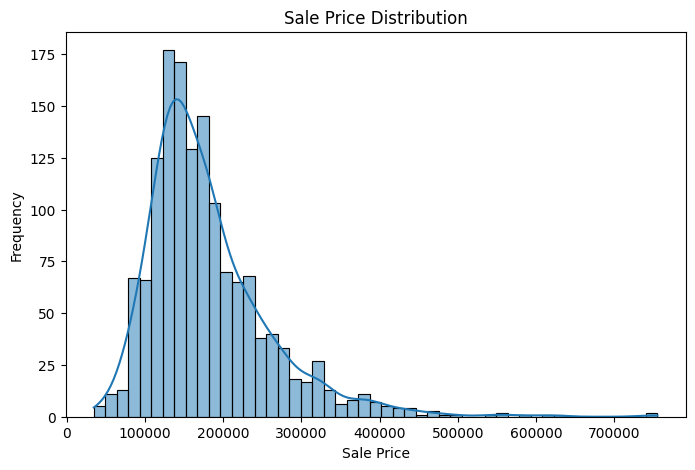

In [5]:
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde = True)
plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

In [8]:
skw = train["SalePrice"].skew()
print(f"Skewness: {skw:.3f}")

# If skewness > 0.75 → highly right-skewed → log transform helps

Skewness: 1.883


<function matplotlib.pyplot.show(close=None, block=None)>

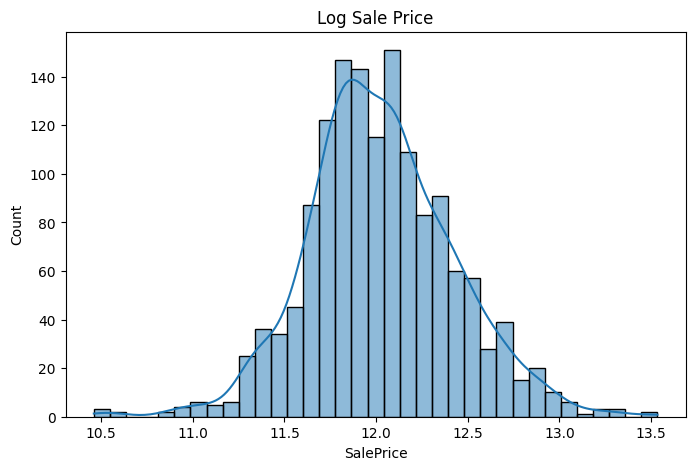

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(train["SalePrice"]), kde = True)
plt.title("Log Sale Price")
plt.show

In [14]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = True)

missing_df = pd.DataFrame({
    'Missing' : missing,
    'MissingPercent' : (missing / len(train)) *100
})

missing_df.head(30)

,Missing,MissingPercent
Electrical,1,0.068493
MasVnrArea,8,0.547945
BsmtQual,37,2.534247
BsmtCond,37,2.534247
BsmtFinType1,37,2.534247
BsmtExposure,38,2.602740
BsmtFinType2,38,2.602740
GarageCond,81,5.547945
GarageQual,81,5.547945
GarageFinish,81,5.547945


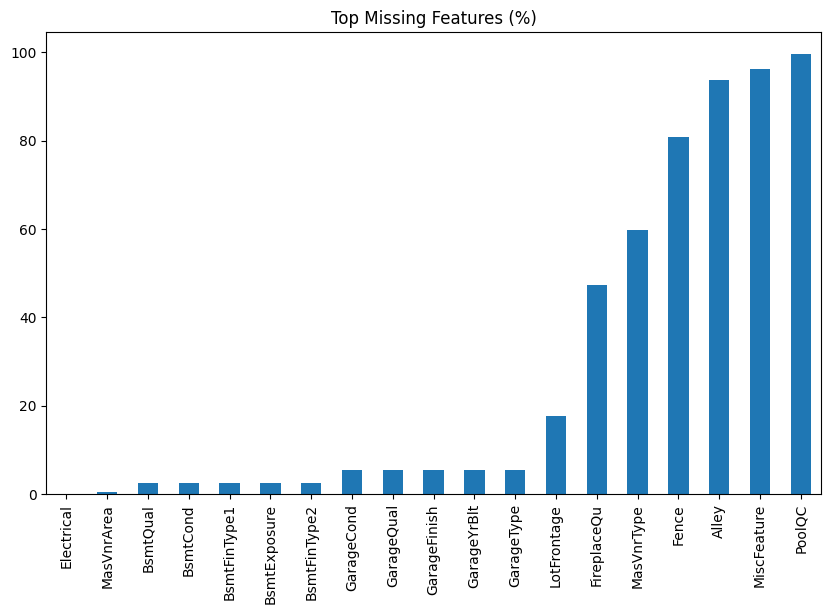

In [15]:
plt.figure(figsize=(10,6))
missing_df['MissingPercent'].head(20).plot(kind='bar')
plt.title("Top Missing Features (%)")
plt.show()

In [16]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
len(num_cols)


38

In [19]:
corr = train[num_cols].corr()

top_corr = corr['SalePrice'].sort_values(ascending = False)
top_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

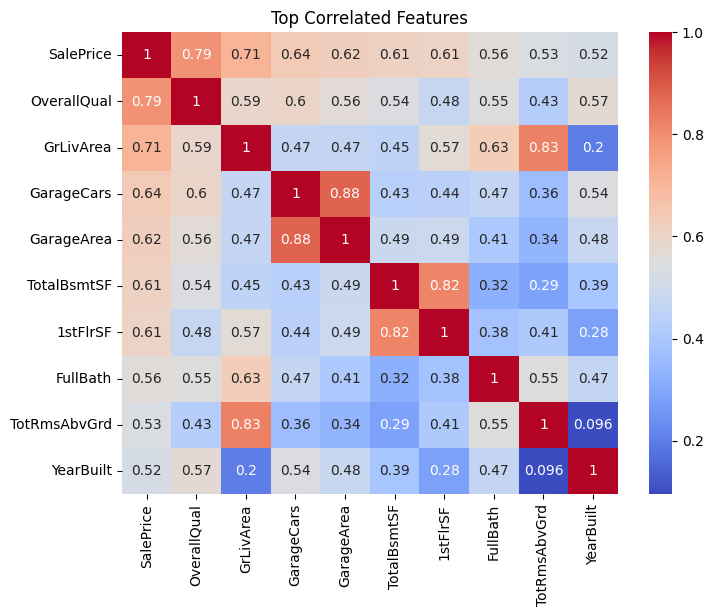

In [21]:
top_features = top_corr.index[:10]

plt.figure(figsize=(8,6))
sns.heatmap(train[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top Correlated Features")
plt.show()

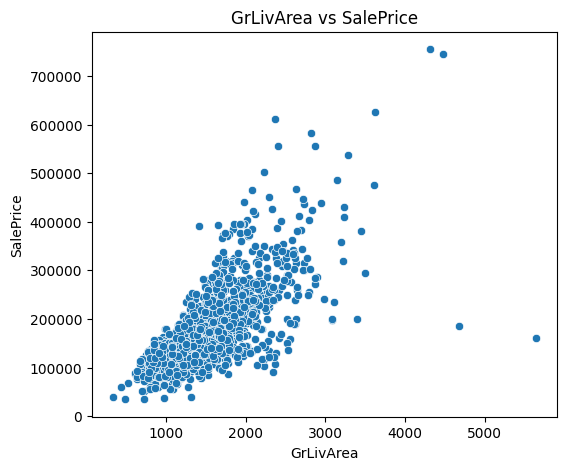

In [23]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.show()

In [27]:
cat_cols = train.select_dtypes(include=['object']).columns
len(cat_cols)

/var/folders/db/7m3gk53d525gp5zsx6q058hc0000gn/T/ipykernel_44420/1589241086.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).columns


43

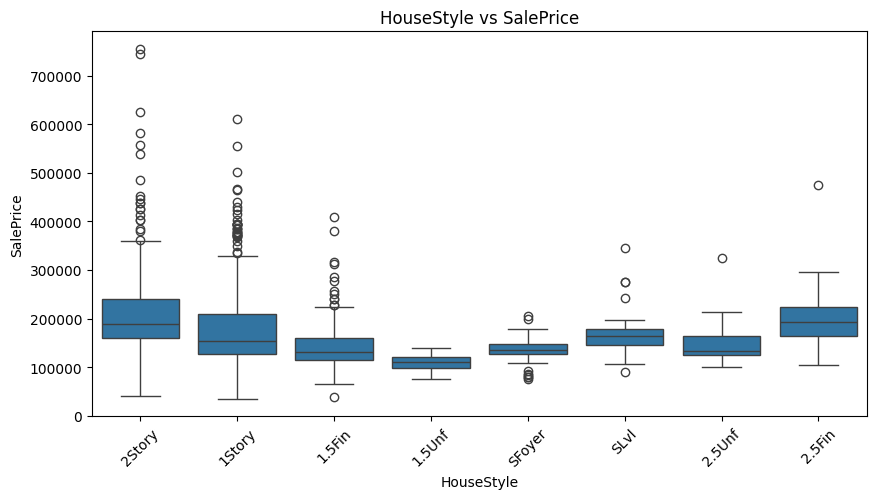

In [30]:
col = 'HouseStyle'

plt.figure(figsize=(10,5))
sns.boxplot(x=train[col], y=train['SalePrice'])
plt.xticks(rotation=45)
plt.title(f"{col} vs SalePrice")
plt.show()

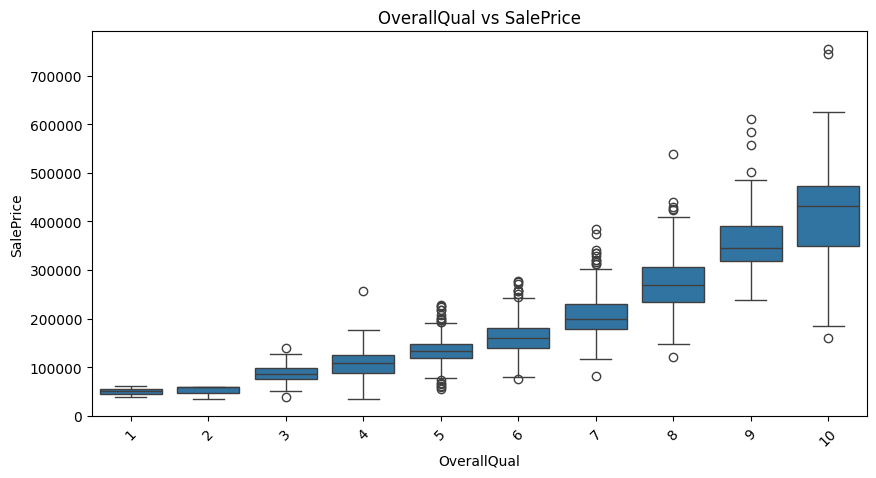

In [31]:
col = 'OverallQual'

plt.figure(figsize=(10,5))
sns.boxplot(x=train[col], y=train['SalePrice'])
plt.xticks(rotation=45)
plt.title(f"{col} vs SalePrice")
plt.show()

In [32]:
train['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

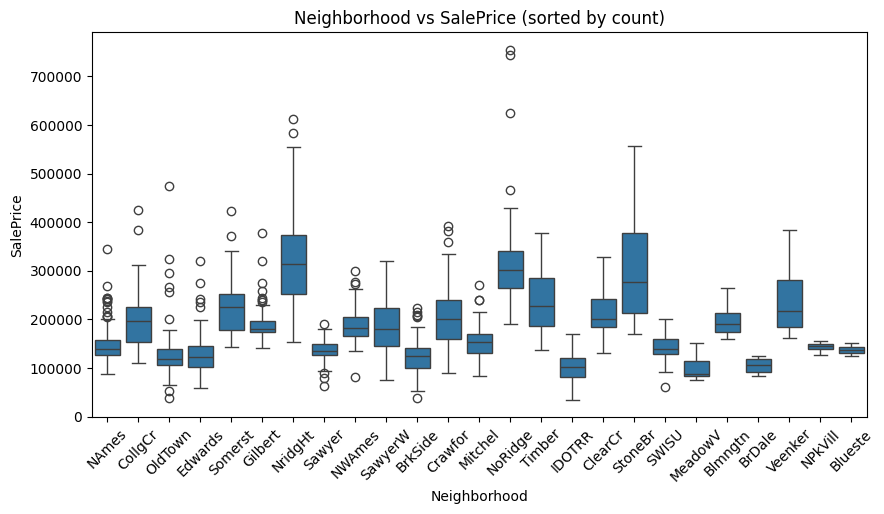

In [33]:
col = 'Neighborhood'

# Get order by count (descending)
order = train[col].value_counts().index

plt.figure(figsize=(10,5))
sns.boxplot(x=train[col], y=train['SalePrice'], order=order)

plt.xticks(rotation=45)
plt.title(f"{col} vs SalePrice (sorted by count)")
plt.show()

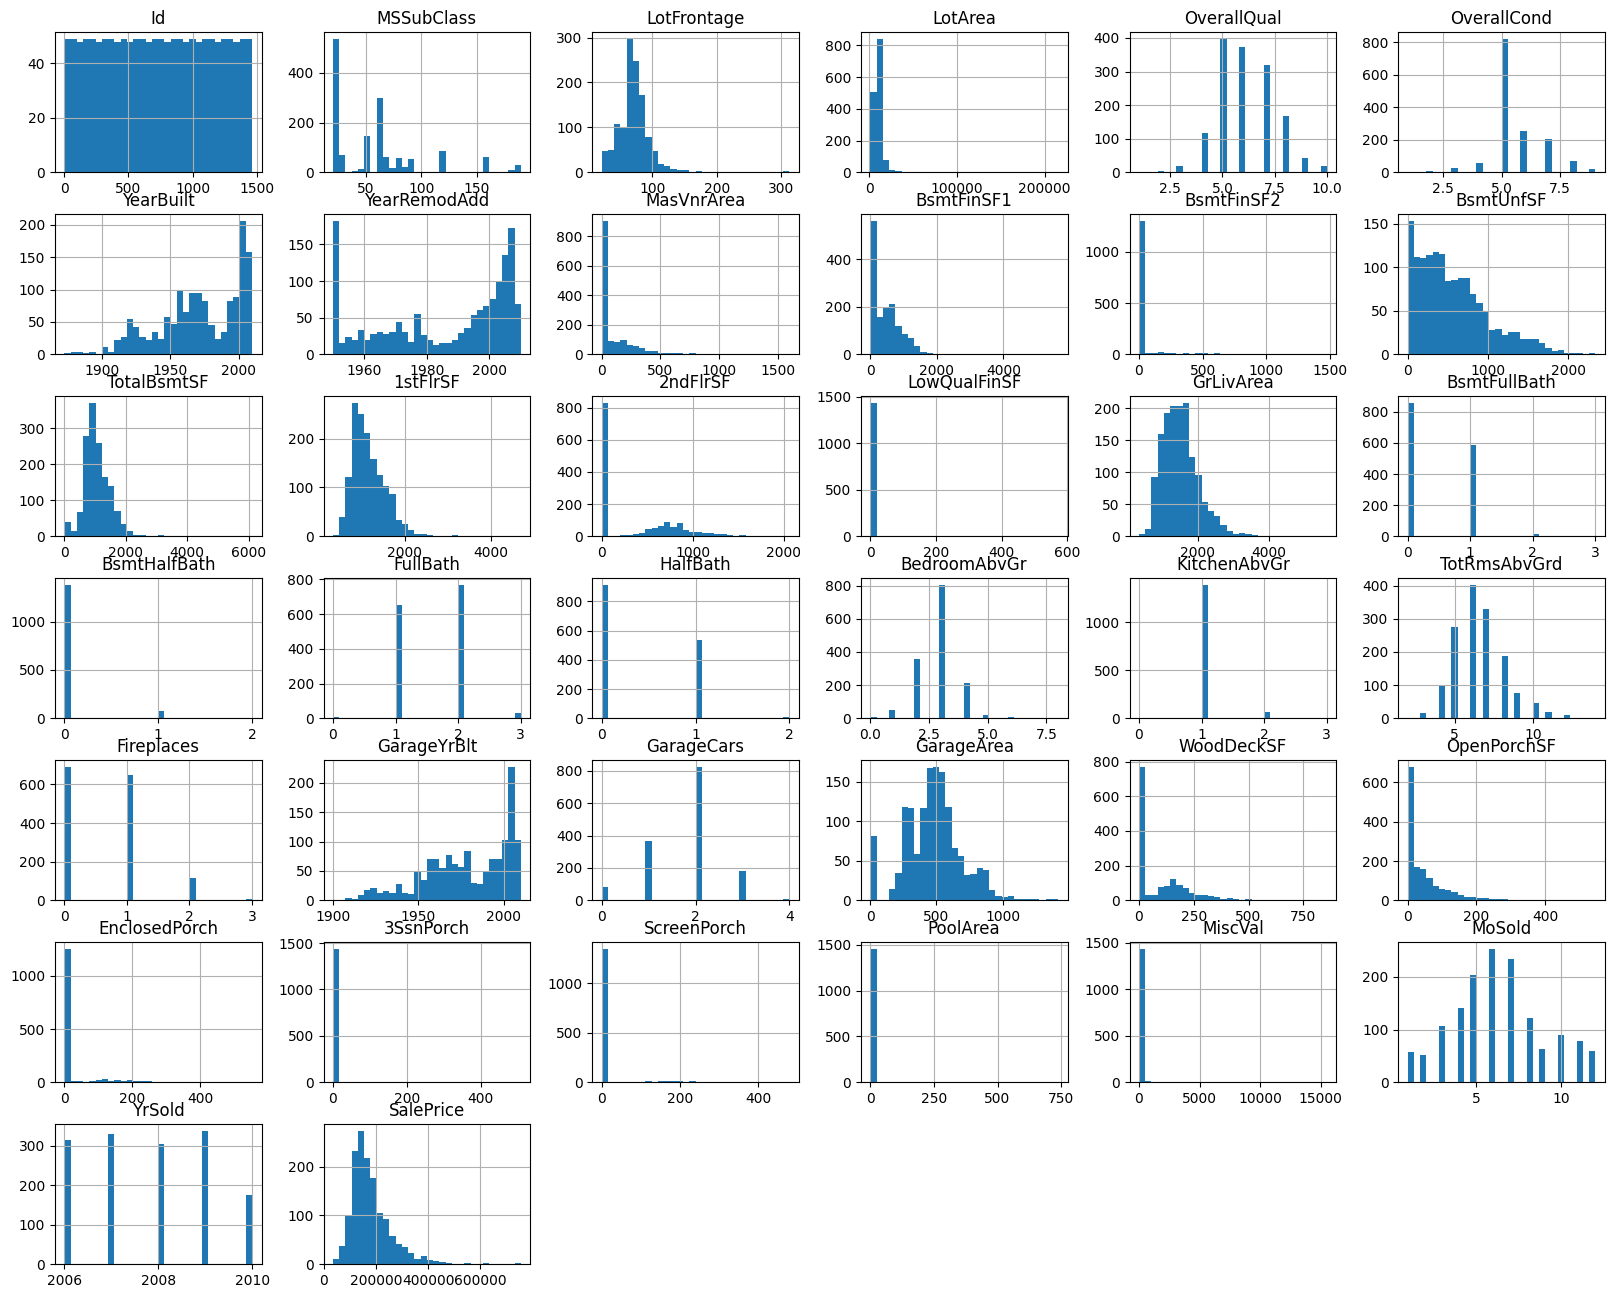

In [35]:
train[num_cols].hist(figsize=(20, 16), bins=30)
plt.show()

In [39]:
skewed = train[num_cols].skew().sort_values(ascending=False)
skewed.head(25)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
dtype: float64

In [41]:
corr_matrix = train[num_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column] > 0.8)]
high_corr

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']

TO-DO: 
- Missing values what to do with each?
- From top numerical features we get that  ->>>>   Sale price = Quality + Size + Garage + Age  ->>>>  think about new features like {TotalSF, HouseAge, RemodAge, HasGarage, HasPool}

EDA results 
1. Price ≈ Quality + Size + Garage + Age
2. GrLivArea and SalePrice both increase, as shown in the graph 
3. What to do with outliers? 
4. Some features are multicolinear, and should be handled 
5. We have top directions (1), handle features now 
6. Encode some features. 
7. Some features like Pool, it either has or not, so maybe we should encode them as 1 and 0 

- Strong signal → keep & improve
- Redundant → combine/drop
- Missing but meaningful → encode
- Weak/noisy → drop

FINAL THOUGHT

- Understand target (SalePrice) → plot distribution, check skewness, apply log1p if needed
- Check missing values → count %, decide: fill "None" / median / drop / binary
- Detect outliers → plot strong features vs target, remove extreme points
- Analyze numerical features → correlation with target, skewness, distributions
- Analyze categorical features → value counts, boxplots vs target, detect ordinal
- Check feature relationships → find multicollinearity (df.corr(), sns.heatmap), redundant features
- Do feature engineering → combine (TotalSF), age features, binary flags
- Transform data → log1p skewed features, scaling if needed
- Encode categorical variables → ordinal mapping + one-hot encoding
- Select features → keep strong, drop weak/redundant
- Validate → cross-validation, RMSE (log target)
- Iterate → improve features based on errors

for multicollinearity:

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [col for col in upper.columns if any(upper[col] > 0.8)]

high_corr